# Wavelength-normalized MRG compositing

Method follows Li et al. (2026), doi:10.1029/2025JD046056.

Straight-line script: load -> KF filter -> find events -> measure L ->
check whether normalization helps -> composite on the normalized axis.


In [17]:
import numpy as np
import pandas as pd
import xarray as xr
import easyclimate as ecl
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

## SETTINGS


In [ ]:
NCFILE =r"C:\Users\norna\Downloads\olr.cbo-1deg.day.anom_2.nc"

LON_DATA   =(20,160)
LON_CENTER =(60,100)   #region of interest
LAT_DATA   =(15,-15)


BAND_N =(5,15)
BAND_S =(-15,-5)

THRESHOLD  =1.0         #sigma of the activity index
MIN_SEP    =5           #days between events
REFINE_WIN =3           #+/- days to shift day 0 onto deepest convection
ACT_BOX    =(60,100,-10,10)  

L_BOUNDS =(8.0,50.0)   #half-wavelength search range,deg
N_X      =81
X_MAX    =1.0           #composite spans -L .. +L
LAGS     =[-2,-1,0,1,2]
FLANK    =0.35          
SN_MRG   =0.5           
SUBSET   ="all"         
ANTISYM_PLOT =True      

DOG2_FOURIER =2.0*np.pi/np.sqrt(2.5)     #=3.973835,Torrence & Compo T1

## 1. LOAD + KF FILTER FOR MRG


In [19]:
ds=xr.open_dataset(NCFILE,decode_times=False)
tv=ds["time"].values
ds=ds.isel(time=(tv>=0) & (tv<1e10))
ds=ds.assign_coords(time=pd.to_datetime(ds["time"].values, unit="h",origin="1800-01-01"))

data=(ds["olr"].sel(time=slice("1991-01-01","2026-08-15")).sel(lat=slice(*LAT_DATA)).interpolate_na(dim="time",method="linear").ffill(dim="time").bfill(dim="time"))

mrg=ecl.filter.kf_filter.kf_filter_mrg_wave(data, steps_per_day=1,tMin=3,tMax=9.6,kMin=-10,kMax=-2,hMin=10,hMax=100)

da =mrg.sel(lon=slice(*LON_DATA),lat=slice(*LAT_DATA))
if da.lat.values[0]>da.lat.values[-1]:
    da=da.sortby("lat")
da=da.sel(time=da.time.dt.month.isin([6,7,8,9]))     # JJAS

lons=da.lon.values.astype(float)
lats=da.lat.values.astype(float)
dlon=float(np.abs(np.diff(lons).mean()))

## 2. ANTISYMMETRIC CENTRING PROFILE

In [20]:
north=da.sel(lat=slice(*BAND_N)).mean(dim="lat")
south=da.sel(lat=slice(*BAND_S)).mean(dim="lat")
dipole=(north-south)                       # (time, lon),antisymmetric index
dip=dipole.values.astype(float)

cmask=(lons>=LON_CENTER[0]) & (lons<=LON_CENTER[1])
csub=np.where(cmask)[0]

## 3. ACTIVITY INDEX


In [21]:
w,e,s,n=ACT_BOX
box=da.sel(lon=slice(w, e), lat=slice(s, n))
index=box.std(dim=["lat", "lon"])
index=(index-index.mean())/index.std()

vals=index.values.astype(float)
times=pd.to_datetime(index.time.values)
peaks,_=find_peaks(np.nan_to_num(vals,nan=-9e9),height=THRESHOLD,distance=MIN_SEP)

# JJAS-only data leaves year-long gaps,so neighbouring indices can be a year.Fixing it
day=times.values.astype("datetime64[D]").astype(np.int64)
seg=np.concatenate([[0],np.cumsum(np.diff(day)!= 1)])

refined = []
for pi in peaks:
    j0,j1=max(0,pi-REFINE_WIN),min(vals.size-1,pi+REFINE_WIN)
    cand=[j for j in range(j0,j1+1) if seg[j]==seg[pi]]
    # deepest convection=most negative dipole
    refined.append(min(cand,key=lambda j: np.nanmin(dip[j][cmask])))
refined=np.asarray(refined,int)

ev=(pd.DataFrame({"date":times[refined],"index_date": times[peaks],"amplitude": vals[peaks],"shift":refined-peaks}).drop_duplicates("date").sort_values("date").reset_index(drop=True))

ev_idx=np.searchsorted(times,ev["date"].values)     # row of each event in dip
sh=ev["shift"].values

print(f"  {len(ev)} events (threshold {THRESHOLD} sigma)")
print(f"  day 0 moved for {np.mean(sh != 0)*100:.0f}% of them")
print(f"  saturated at +/-{REFINE_WIN} d for {np.mean(np.abs(sh) == REFINE_WIN)*100:.0f}% ")
print(f"  mean |shift| {np.mean(np.abs(sh)):.2f} d")

  161 events (threshold 1.0 sigma)
  day 0 moved for 78% of them
  saturated at +/-3 d for 14% 
  mean |shift| 1.40 d


## 4. HALF-WAVELENGTH L PER EVENT  (Mexican hat wavelet)


In [ ]:
def half_wavelength(profile, ci, method="wavelet"):
    """Half-wavelength in degrees at longitude index ci, or nan."""
    p=np.asarray(profile,float)
    if not np.any(np.isfinite(p)):
        return np.nan
    p=np.nan_to_num(p-0.0)

    if method=="wavelet":
        scales=np.geomspace(2.0*L_BOUNDS[0]/DOG2_FOURIER/dlon,2.0*L_BOUNDS[1]/DOG2_FOURIER/dlon,200)
        t=(np.arange(p.size)-ci).astype(float)
        norm=2.0/(np.sqrt(3.0)*np.pi**0.25)
        power=np.empty(scales.size)
        for i,sc in enumerate(scales):
            u=t/sc
            psi=norm*(1.0-u**2)*np.exp(-0.5*u**2)
            power[i]=(np.sum(p*psi)/np.sqrt(sc))**2
        k=int(np.argmax(power))
        if k==0 or k==scales.size-1:
            return np.nan          
        L=0.5*DOG2_FOURIER*scales[k]*dlon
    else:
        sgn=np.sign(p[ci])
        if sgn==0:
            return np.nan
        r=next((k for k in range(ci+1,p.size) if np.sign(p[k])!=sgn), None)
        l=next((k for k in range(ci-1,-1,-1) if np.sign(p[k])!=sgn), None)
        if r is None or l is None:
            return np.nan
        L=(r-l)*dlon

    return L if L_BOUNDS[0]<= L<=L_BOUNDS[1] else np.nan

L_deg,lon_c=np.full(len(ev),np.nan),np.full(len(ev),np.nan)
L_zc=np.full(len(ev),np.nan)
sn=np.full(len(ev),np.nan)              
pn,ps=north.values.astype(float),south.values.astype(float)
for j,it in enumerate(ev_idx):
    prof=dip[it]
    ci=int(csub[np.nanargmin(prof[cmask])])          # deepest convection
    lon_c[j]=lons[ci]
    L_deg[j]=half_wavelength(prof, ci, "wavelet")
    L_zc[j]=half_wavelength(prof, ci, "zerocross")


    a_n=np.nanmax(np.abs(pn[it][cmask]))
    a_s=np.nanmax(np.abs(ps[it][cmask]))
    sn[j]=a_s/a_n if a_n>0 else np.nan

ok=np.isfinite(L_deg)
Lbar=np.nanmean(L_deg[ok])
km=111.195*np.cos(np.deg2rad(10.0))               # at the lobe latitude
print(f"\nL measured for {ok.sum()}/{len(ev)} events")
print(f"  mean L {Lbar:.1f} deg  (full wavelength ~{2*Lbar*km:.0f} km)")
print(f"  std L  {np.nanstd(L_deg[ok]):.1f} deg    CV {np.nanstd(L_deg[ok])/Lbar:.2f}")
both=ok & np.isfinite(L_zc)
gap=abs(np.nanmean(L_deg[both])-np.nanmean(L_zc[both]))/Lbar

##MRG vs TD
# S/N~1:antisymmetric(MRG)
# S/N~0:northern lobe only(TD-type)
mrg_like=ok & (sn>=SN_MRG)
td_like=ok & (sn<SN_MRG)

print(f"  median S/N {np.nanmedian(sn[ok]):.2f}")
print(f"  MRG-like (S/N>={SN_MRG}):{mrg_like.sum()} events")
print(f"  TD-like  (S/N<{SN_MRG}):{td_like.sum()} events")
if mrg_like.sum():
    print(f"  mean L, MRG-like : {np.nanmean(L_deg[mrg_like]):.1f} deg"
          f"   CV {np.nanstd(L_deg[mrg_like])/np.nanmean(L_deg[mrg_like]):.2f}")
if td_like.sum():
    print(f"  mean L, TD-like  : {np.nanmean(L_deg[td_like]):.1f} deg"
          f"   CV {np.nanstd(L_deg[td_like])/np.nanmean(L_deg[td_like]):.2f}")
print("Not population mixing.")




L measured for 137/161 events
  mean L 30.4 deg  (full wavelength ~6660 km)
  std L  7.7 deg    CV 0.25
  median S/N 0.35
  MRG-like (S/N>=0.5):38 events
  TD-like  (S/N<0.5):99 events
  mean L, MRG-like : 30.7 deg   CV 0.27
  mean L, TD-like  : 30.3 deg   CV 0.25
Not population mixing.


## 5.Normalization check


  centred in degrees :64% of ceiling
  normalized by L    :73% of ceiling
  gain               :1.14x


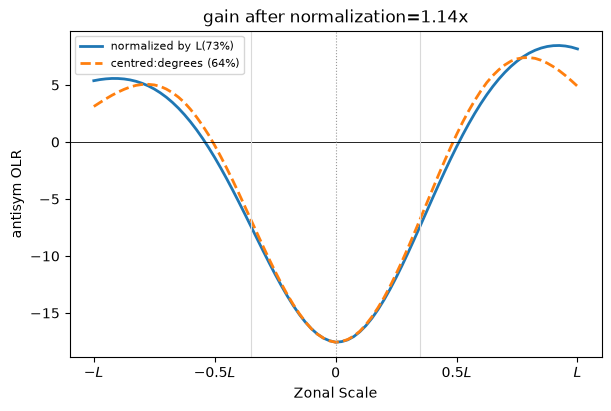

In [23]:
x=np.linspace(-X_MAX,X_MAX,N_X)
d_grid=x*Lbar                       # same axis in deg

st_deg=np.full((len(ev),N_X),np.nan)
st_nrm=np.full((len(ev),N_X),np.nan)
own=[]
for j,it in enumerate(ev_idx):
    if not ok[j]:
        continue
    prof,c,L=dip[it],lon_c[j],L_deg[j]
    g=np.isfinite(prof)
    for tgt,store in ((c+d_grid,st_deg),(c+x*L,st_nrm)):
        if tgt[0]<lons.min() or tgt[-1]>lons.max():
            continue                    
        store[j]=np.interp(tgt,lons[g],prof[g])
    if np.isfinite(st_nrm[j]).all():
        own.append(np.nanmax(np.abs(st_nrm[j][np.abs(x)>FLANK])))

flank=np.abs(x)>FLANK
p_deg,p_nrm=np.nanmean(st_deg,axis=0),np.nanmean(st_nrm,axis=0)
ceil=np.mean(own)                     # each event's own flank amplitude
coh_deg=np.nanmax(np.abs(p_deg[flank]))/ceil
coh_nrm=np.nanmax(np.abs(p_nrm[flank]))/ceil
gain=coh_nrm/coh_deg

n_kept = int(np.isfinite(st_nrm[:,0]).sum())
print(f"  centred in degrees :{100*coh_deg:.0f}% of ceiling")
print(f"  normalized by L    :{100*coh_nrm:.0f}% of ceiling")
print(f"  gain               :{gain:.2f}x")

fig,ax=plt.subplots(figsize=(6,4),constrained_layout=True)
ax.plot(x,p_nrm,lw=2,label=f"normalized by L({100*coh_nrm:.0f}%)")
ax.plot(x,p_deg,lw=2,ls="--",label=f"centred:degrees ({100*coh_deg:.0f}%)")
ax.axhline(0,color="k",lw=0.6);ax.axvline(0,color="0.6",lw=0.8,ls=":")
for v in (-FLANK,FLANK):
    ax.axvline(v,color="0.85",lw=0.8)
ax.set_xticks([-1,-0.5,0,0.5,1])
ax.set_xticklabels(["$-L$","$-0.5L$","0","$0.5L$","$L$"])
ax.set_xlabel("Zonal Scale")
ax.set_ylabel("antisym OLR")
ax.set_title(f"gain after normalization={gain:.2f}x")
ax.legend(fontsize=8)
plt.show()

## 6. THE COMPOSITE, lat-lon on the normalized axis



composite S/N (south lobe/north lobe)=0.26


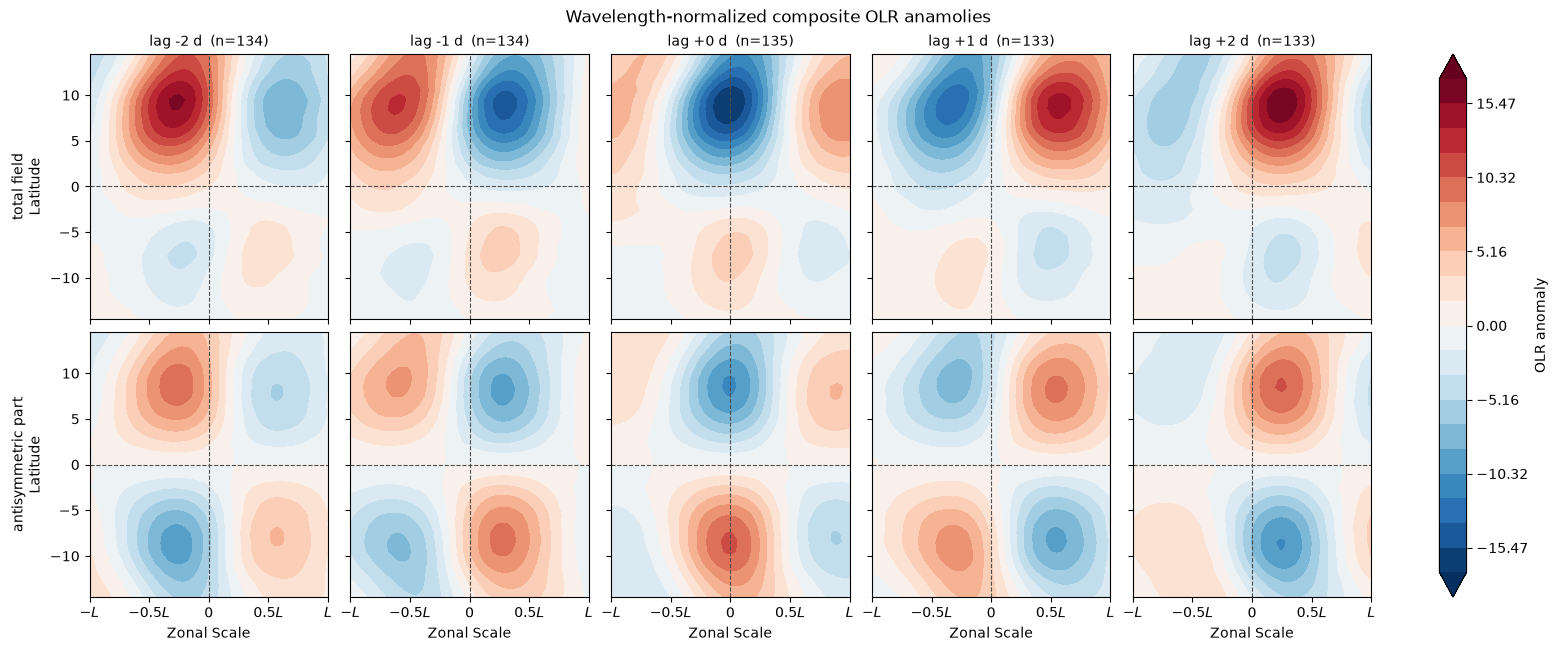

In [ ]:
use={"all":ok,"mrg":mrg_like,"td":td_like}[SUBSET]
comp=np.full((len(LAGS),lats.size, N_X),np.nan)
nlag=np.zeros(len(LAGS),int)

for i,lag in enumerate(LAGS):
    stack=np.full((len(ev),lats.size,N_X),np.nan)
    for j,it in enumerate(ev_idx):
        k=it+lag
        if not use[j] or k<0 or k>=times.size or seg[k]!=seg[it]:
            continue
        tgt=lon_c[j]+x*L_deg[j]
        if tgt[0]<lons.min() or tgt[-1]>lons.max():
            continue
        fld=da.isel(time=k).transpose("lat","lon").values.astype(float)
        for m in range(lats.size):
            row=fld[m]
            g=np.isfinite(row)
            if g.sum()>1:
                stack[j,m]=np.interp(tgt,lons[g],row[g])
    comp[i]=np.nanmean(stack,axis=0)
    nlag[i]=int(np.isfinite(stack[:,0,0]).sum())


comp_anti=0.5*(comp-comp[:,::-1,:])
print(f"\ncomposite S/N (south lobe/north lobe)="f"{np.nanmax(np.abs(comp[:,lats<=-5,:]))/np.nanmax(np.abs(comp[:,lats>= 5,:])):.2f}")

rows=[("total field",comp)]+([("antisymmetric part", comp_anti)]
                                  if ANTISYM_PLOT else [])
vmax=np.nanmax(np.abs(comp))
levels=np.linspace(-vmax, vmax,21)
fig,axes=plt.subplots(len(rows),len(LAGS),
                         figsize=(3.1*len(LAGS),3.2*len(rows)),
                         sharex=True,sharey=True,squeeze=False,
                         constrained_layout=True)
for r,(rname,arr) in enumerate(rows):
    for i in range(len(LAGS)):
        ax=axes[r][i]
        cf=ax.contourf(x,lats,arr[i],levels=levels,cmap="RdBu_r",extend="both")
        ax.axvline(0,color="0.3",lw=0.8,ls="--")
        ax.axhline(0,color="0.3",lw=0.8,ls="--")
        if r==0:
            ax.set_title(f"lag {LAGS[i]:+d} d  (n={nlag[i]})", fontsize=10)
        ax.set_xticks([-1,-0.5,0,0.5,1])
        ax.set_xticklabels(["$-L$","$-0.5L$","0","$0.5L$","$L$"])
        if r==len(rows)-1:
            ax.set_xlabel("Zonal Scale")
    axes[r][0].set_ylabel(f"{rname}\nLatitude")
fig.colorbar(cf,ax=axes,label="OLR anomaly")
fig.suptitle(f"Wavelength-normalized composite OLR anamolies ")
plt.show()